In [1]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.common import kb_eV, T, kb_J, h, F, N_A
from _CO_Oxidation import wrapper_base as wp
from _CO_Oxidation.wrapper_base import plot_posteriors, plot_model_fits, plot_coverages, plot_drc

C_KOH_list = np.array([0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = pickle.load(open('import_Ag10Pd90_base_replicates.pkl', 'rb'))
wp.process_experimental_data(experiments_data, C_KOH_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_KOH_in = wp.C_KOH_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    rate_model = pt.exp(log_rate)
    sigma_rel = pm.Gamma('sigma_rel', alpha=2, beta=20)
    sigma_base = pm.HalfNormal('sigma_base', sigma=1e-2)
    exponent =  pm.HalfNormal('exponent', sigma=1)
    sigma_model = pt.sqrt(sigma_base**2 + (sigma_rel**2)*(rate_model ** exponent))
    # sigma_total = pt.sqrt(wp.rate_SD_obs**2 + sigma_model**2)
    rate = pm.StudentT('rate', nu=4, mu=rate_model, sigma=sigma_model, observed=wp.rate_obs_matrix)
    return rate

Ag_comp = 0.1

# BF

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.35,15
,3000,0,0.38,31
,3000,0,0.35,7
,3000,0,0.39,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  1937.96    67.06
p_loo        7.68        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



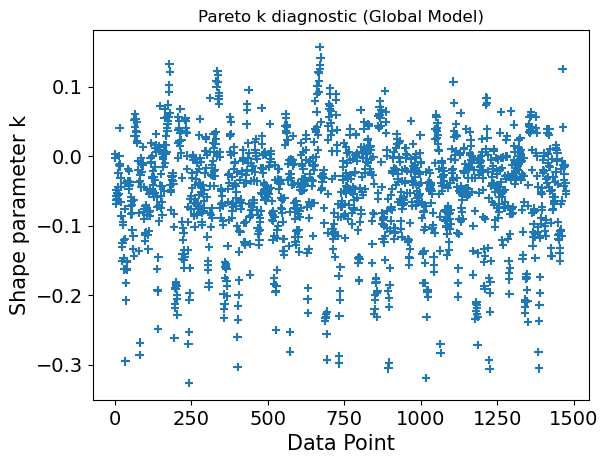

In [2]:
with pm.Model() as BF:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH# -> COOH* + # (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    rate = observables(log_rate) 

trace_BF, loo_BF = fit_and_evaluate(BF)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.088  0.003  -0.093   -0.082      0.000    0.000    2448.0    2439.0    1.0
deltaG4_0   0.343  0.088   0.208    0.500      0.002    0.003    2039.0    1310.0    1.0
deltaG5_0  -0.003  0.004  -0.011    0.004      0.000    0.000    1792.0    2369.0    1.0
Gact2_0     0.681  0.001   0.678    0.683      0.000    0.000    1751.0    1851.0    1.0
sigma_rel   0.311  0.014   0.287    0.339      0.000    0.000    2571.0    2727.0    1.0
sigma_base  0.000  0.000   0.000    0.001      0.000    0.000    2492.0    1535.0    1.0
exponent    0.795  0.018   0.758    0.828      0.000    0.000    2082.0    2447.0    1.0


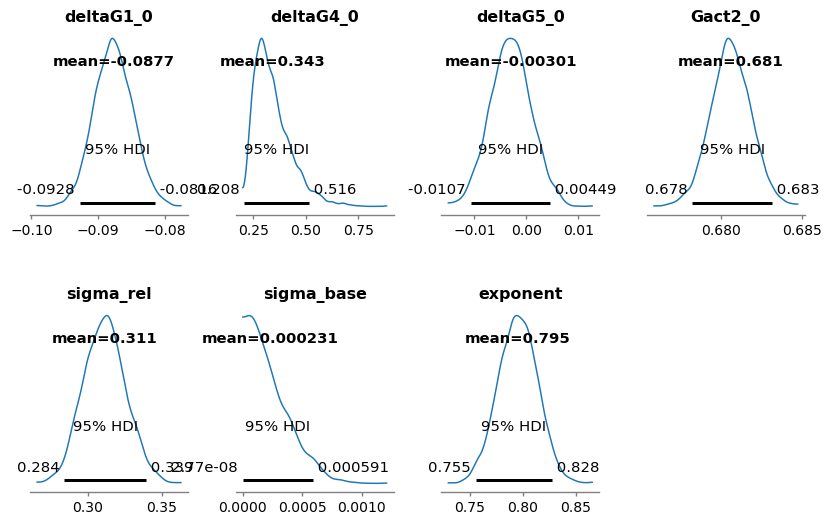

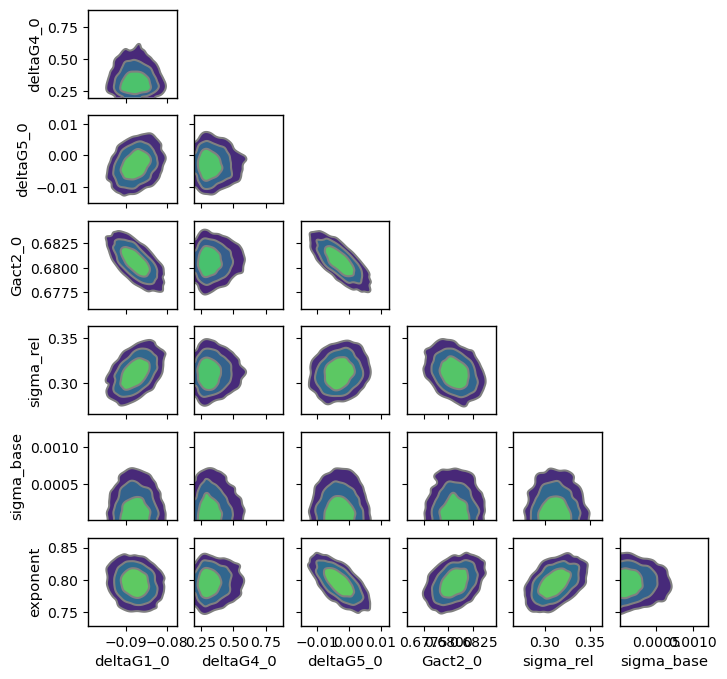

Sampling: [rate]


rate: 0.614


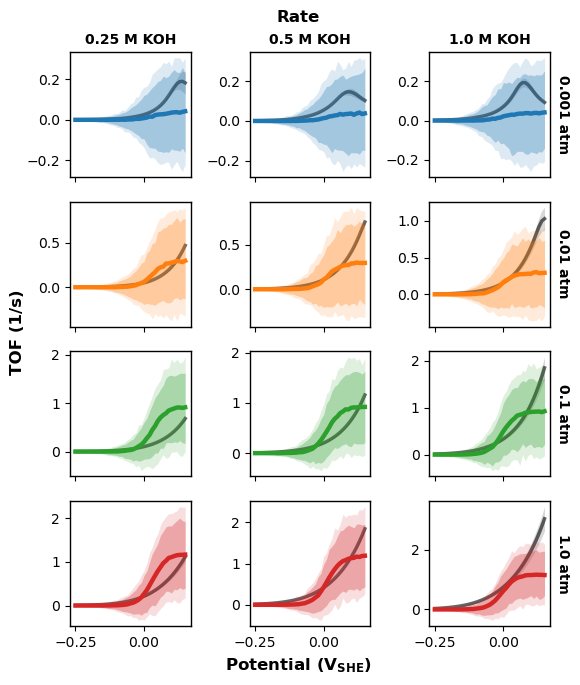

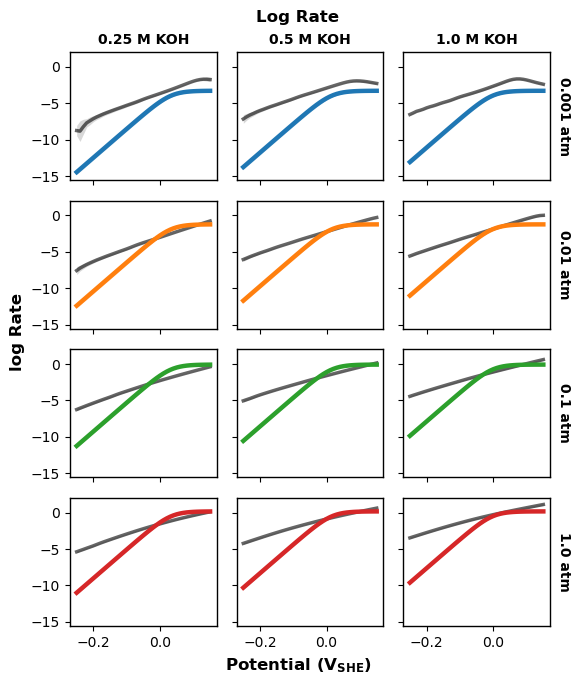

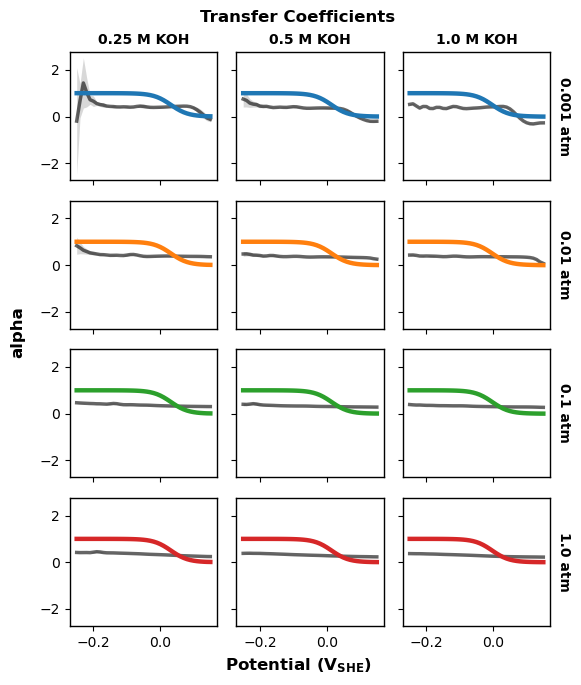

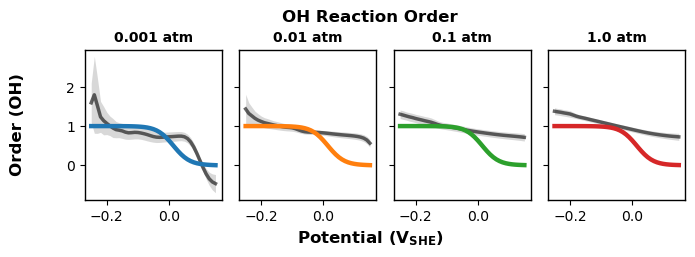

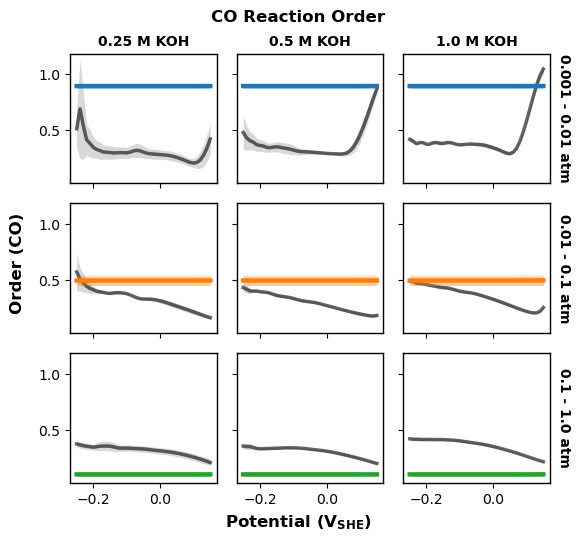

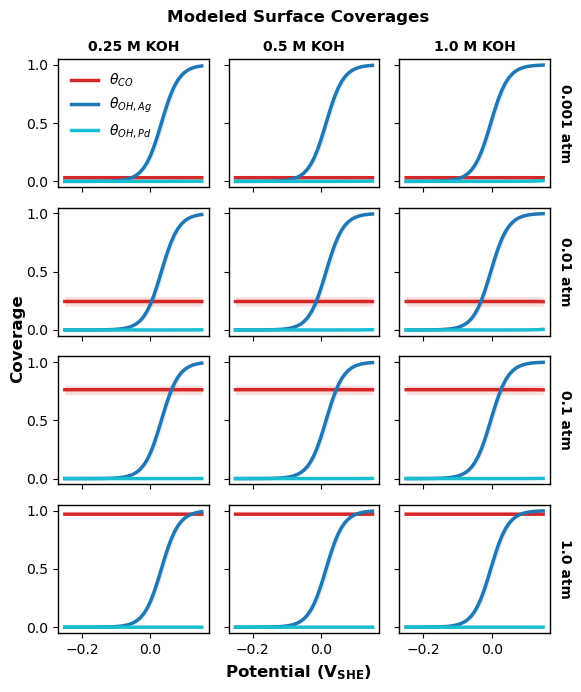

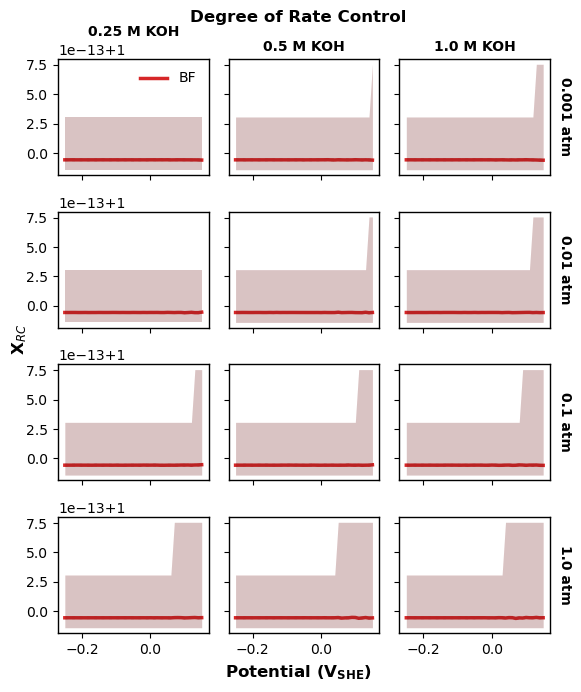

In [3]:
ppc_BF = plot_posteriors(trace_BF, BF)
plot_model_fits(trace_BF, ppc_BF); plot_coverages(trace_BF)
plot_drc(BF, trace_BF, perturb_vars=['Gact2_0'], perturb_labels=['BF'])

# ER 2 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.43,7
,3000,0,0.46,3
,3000,0,0.50,15
,3000,0,0.45,7


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  2941.73    73.15
p_loo        7.35        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



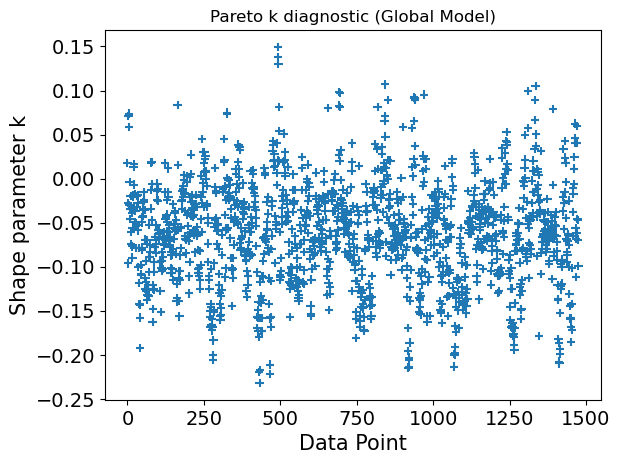

In [4]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.126  0.001  -0.128   -0.124      0.000    0.000    2528.0    2679.0    1.0
deltaG4_0   0.112  0.003   0.107    0.118      0.000    0.000    3064.0    2770.0    1.0
deltaG5_0   0.002  0.200  -0.357    0.384      0.003    0.003    4550.0    3195.0    1.0
Gact2_0     0.762  0.000   0.761    0.763      0.000    0.000    2644.0    2819.0    1.0
beta_2      0.350  0.003   0.344    0.356      0.000    0.000    3625.0    3393.0    1.0
sigma_rel   0.323  0.015   0.295    0.351      0.000    0.000    2096.0    2422.0    1.0
sigma_base  0.000  0.000   0.000    0.000      0.000    0.000    2059.0    1066.0    1.0
exponent    1.837  0.029   1.781    1.890      0.001    0.001    2058.0    2166.0    1.0


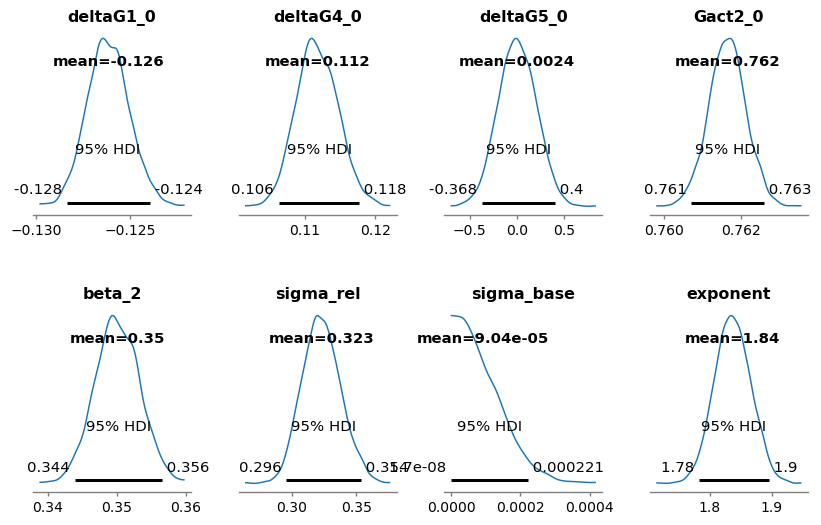

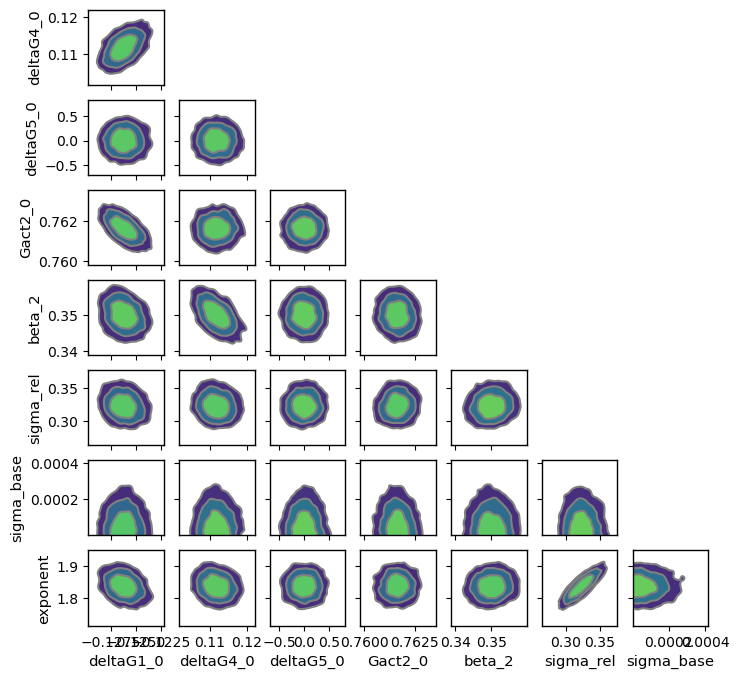

Sampling: [rate]


rate: 0.753


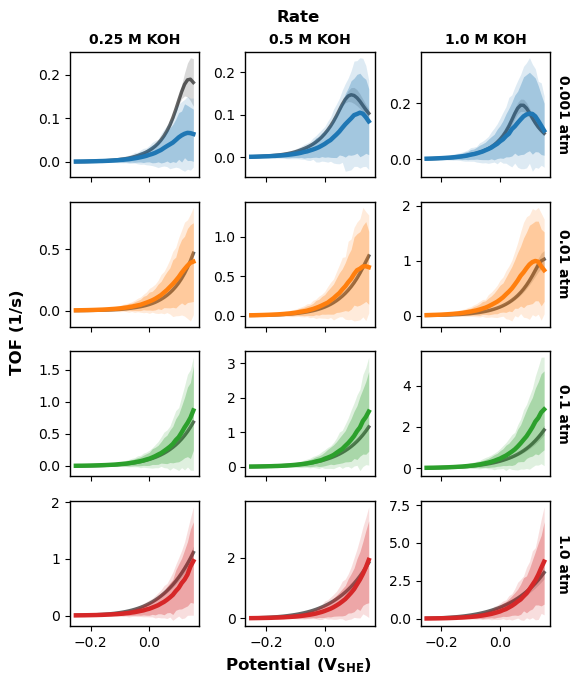

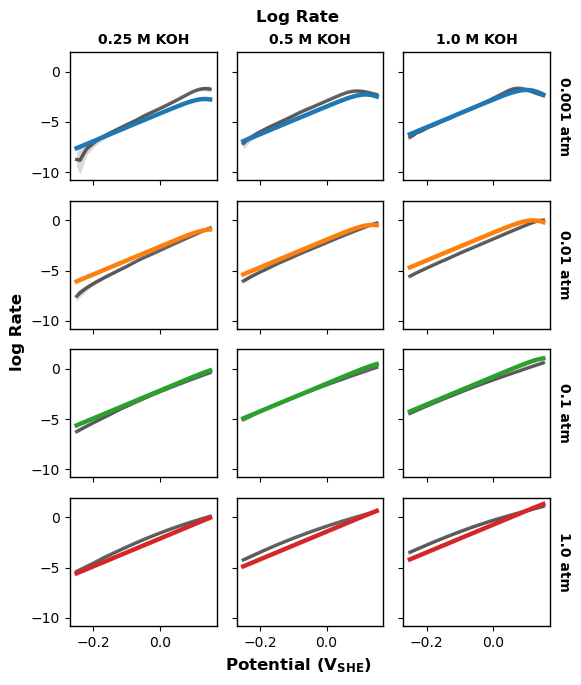

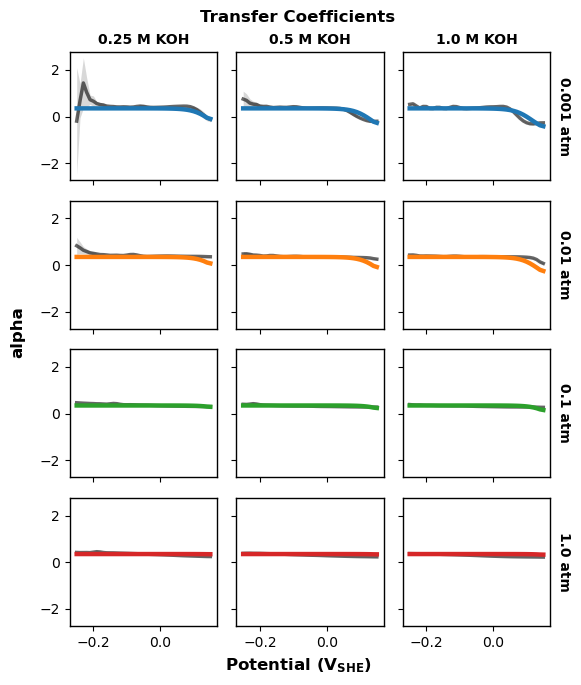

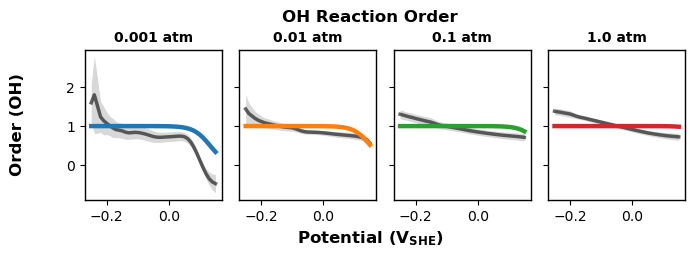

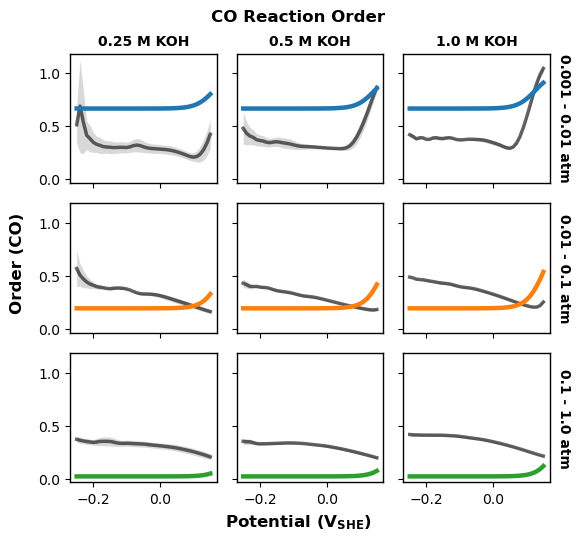

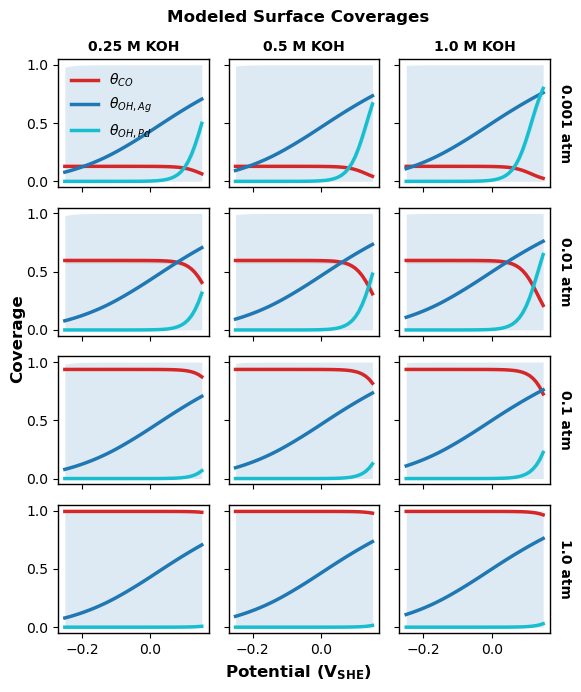

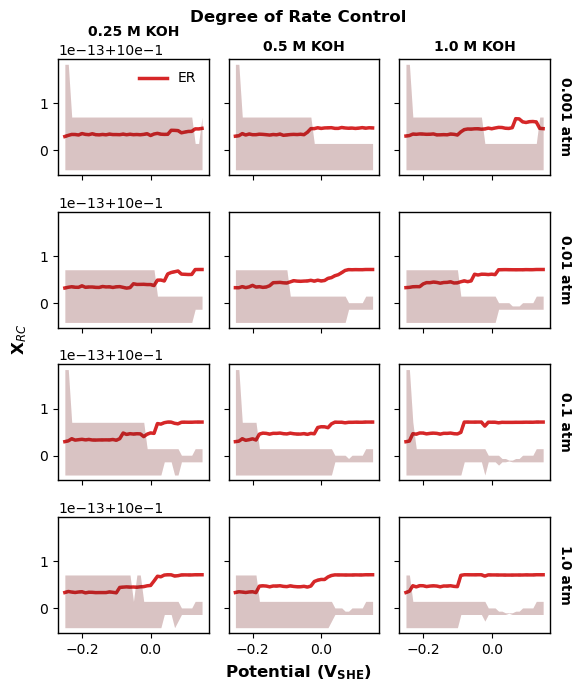

In [5]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)
plot_drc(ER_2, trace_ER_2, perturb_vars=['Gact2_0'], perturb_labels=['ER'])

# BF ER 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.35,3
,3000,0,0.38,15
,3000,0,0.40,15
,3000,0,0.39,31


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  2986.74    72.47
p_loo       12.78        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



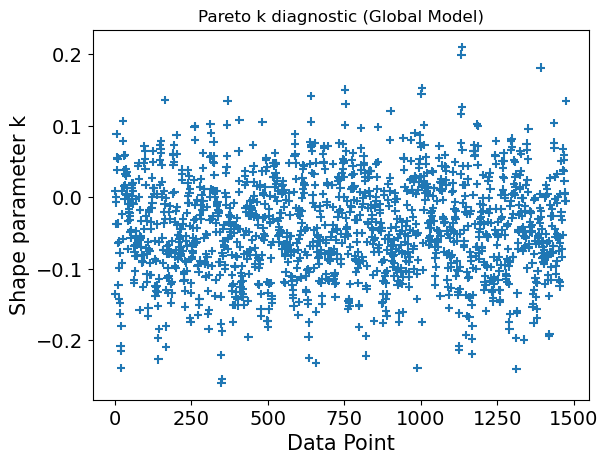

In [6]:
with pm.Model() as BF_ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH# -> COOH* + # (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2_BF = Gact2_BF_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_ER)
    rate = observables(log_rate) 

trace_BF_ER_2, loo_BF_ER_2 = fit_and_evaluate(BF_ER_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.125  0.001  -0.127   -0.123      0.000    0.000    3262.0    2770.0    1.0
deltaG4_0   0.127  0.004   0.119    0.135      0.000    0.000    2701.0    2509.0    1.0
deltaG5_0  -0.043  0.011  -0.064   -0.023      0.000    0.000    1826.0    1946.0    1.0
Gact2_BF_0  0.737  0.005   0.727    0.746      0.000    0.000    1559.0    1756.0    1.0
Gact2_ER_0  0.766  0.001   0.765    0.768      0.000    0.000    2099.0    2465.0    1.0
beta_2      0.333  0.005   0.323    0.342      0.000    0.000    1827.0    2003.0    1.0
sigma_rel   0.309  0.014   0.284    0.336      0.000    0.000    2475.0    2525.0    1.0
sigma_base  0.000  0.000   0.000    0.000      0.000    0.000    2126.0    1301.0    1.0
exponent    1.829  0.029   1.774    1.884      0.001    0.001    2405.0    2271.0    1.0


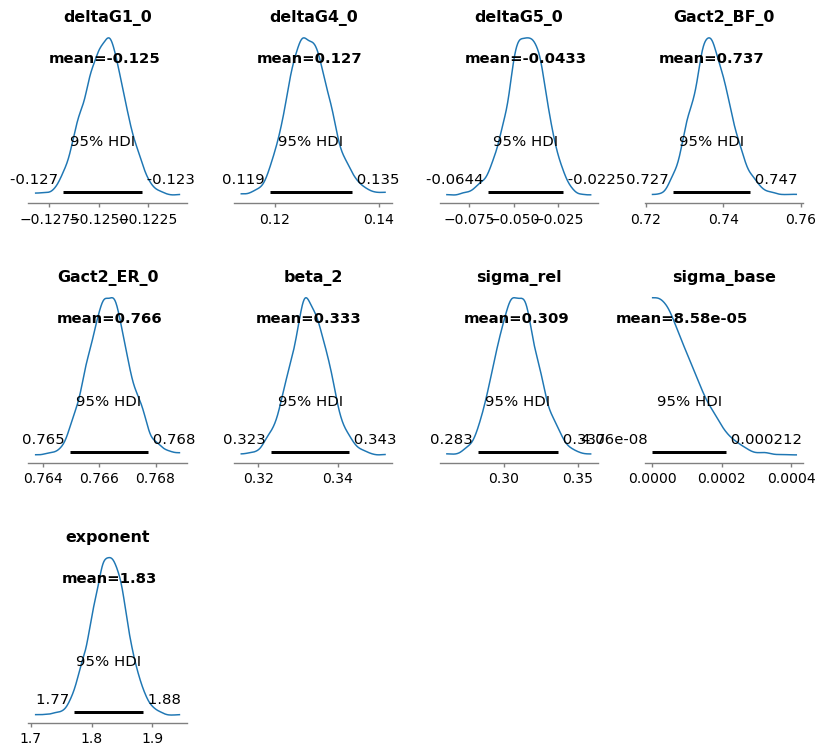

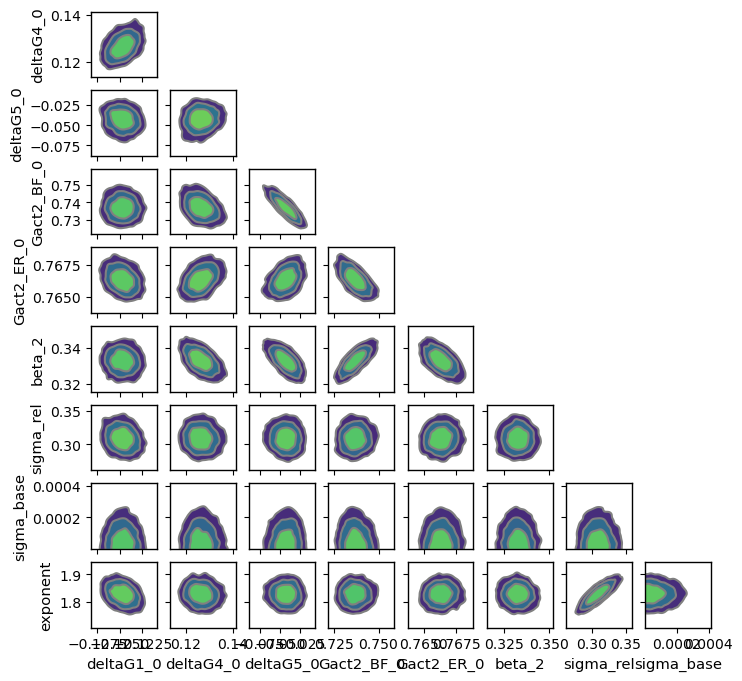

Sampling: [rate]


rate: 0.757


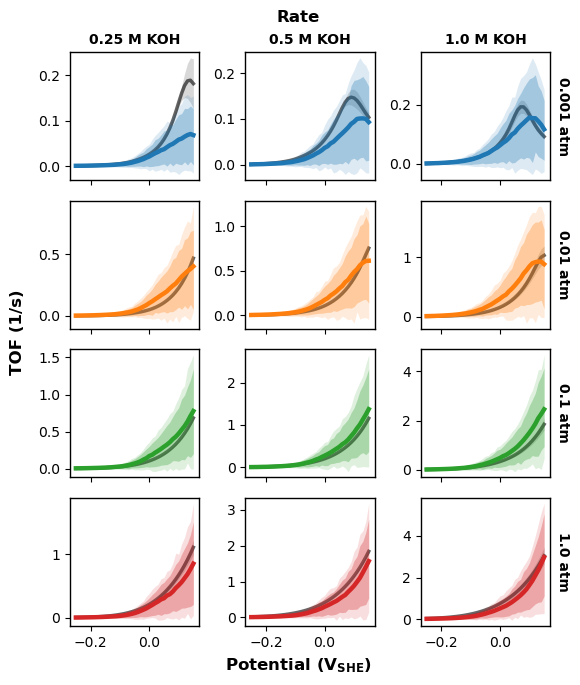

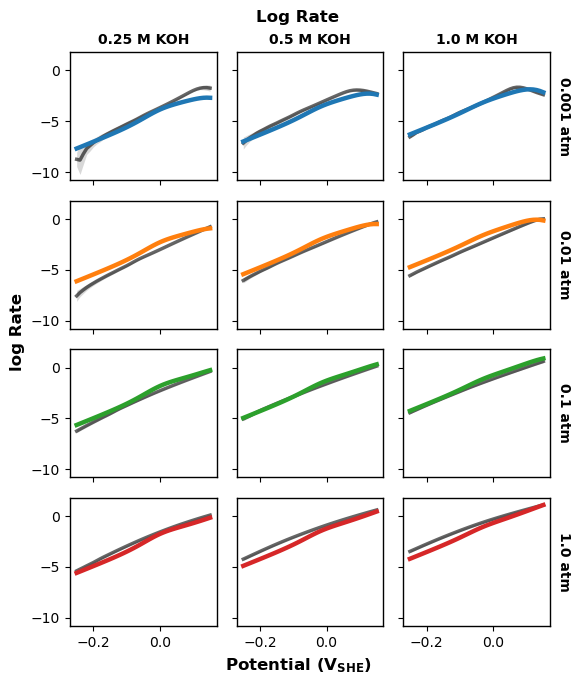

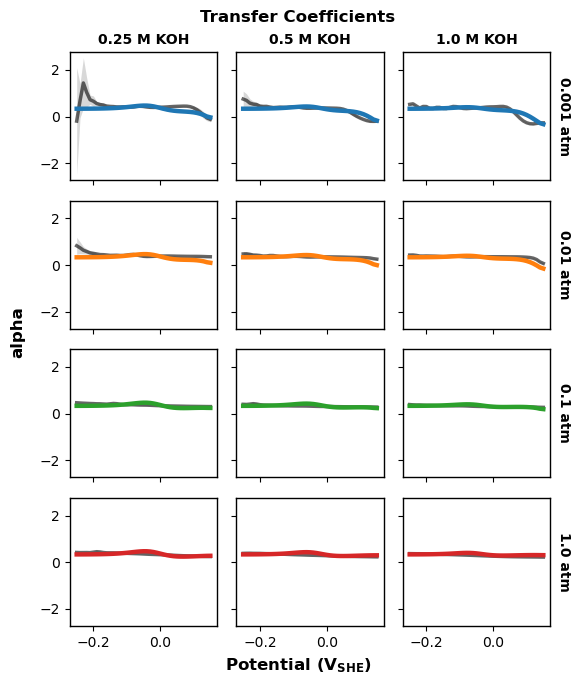

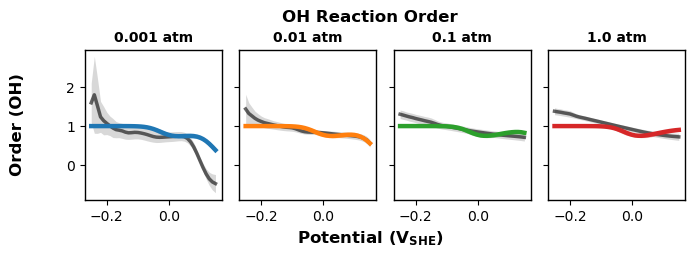

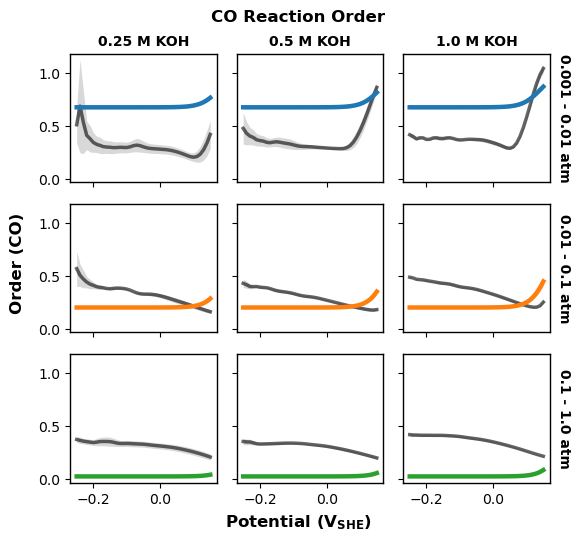

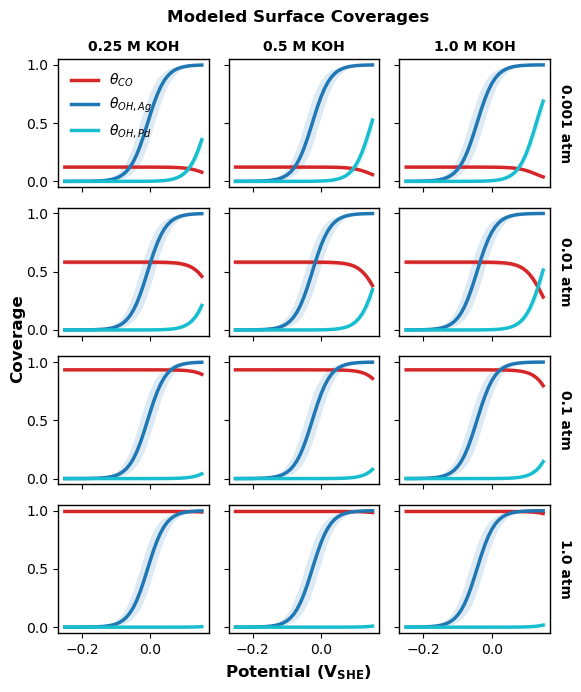

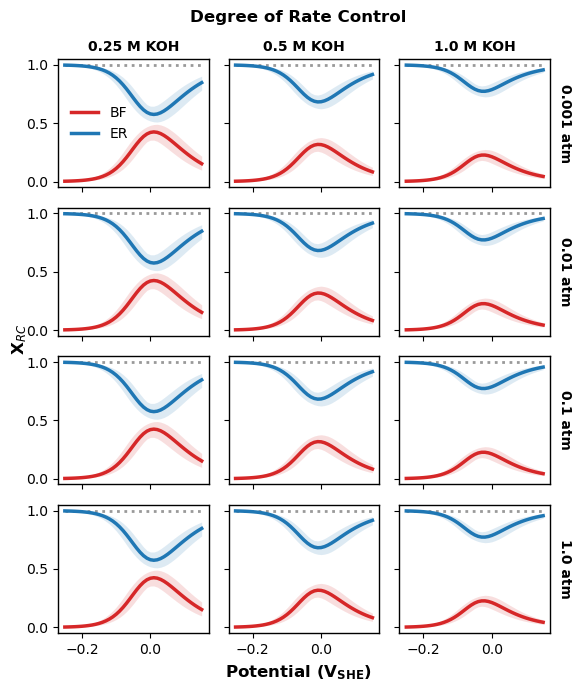

In [7]:
ppc_BF_ER_2 = plot_posteriors(trace_BF_ER_2, BF_ER_2)
plot_model_fits(trace_BF_ER_2, ppc_BF_ER_2); plot_coverages(trace_BF_ER_2)
plot_drc(BF_ER_2, trace_BF_ER_2, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0'], perturb_labels=['BF', 'ER'])

# BF ER LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.41,31
,3000,0,0.36,15
,3000,0,0.39,15
,3000,0,0.38,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  3017.45    72.25
p_loo       13.71        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



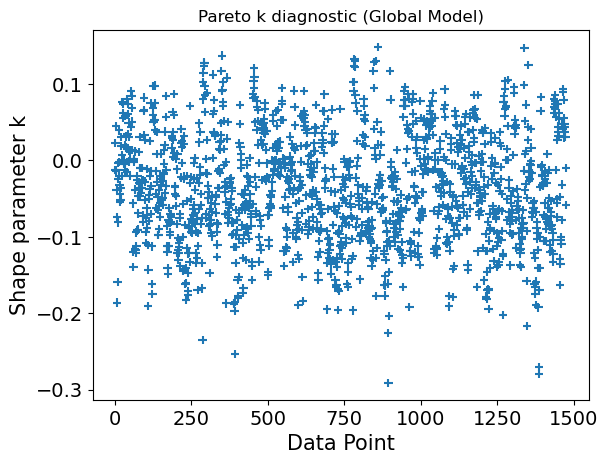

In [8]:
with pm.Model() as BF_ER_LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH# -> COOH* + # (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    2c. CO* + OH* -> COOH* + * (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2_BF = Gact2_BF_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    log_rate = pt.logsumexp(pt.stack([log_rate_BF, log_rate_ER, log_rate_LH]), axis=0)
    rate = observables(log_rate) 

trace_BF_ER_LH_2, loo_BF_ER_LH_2 = fit_and_evaluate(BF_ER_LH_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.123  0.001  -0.125   -0.121      0.000      0.0    3445.0    2687.0    1.0
deltaG4_0   0.102  0.003   0.097    0.108      0.000      0.0    3126.0    2998.0    1.0
deltaG5_0  -0.070  0.011  -0.091   -0.049      0.000      0.0    1808.0    2826.0    1.0
Gact2_BF_0  0.748  0.005   0.738    0.757      0.000      0.0    1638.0    2102.0    1.0
Gact2_ER_0  0.766  0.001   0.765    0.768      0.000      0.0    2610.0    2717.0    1.0
Gact2_LH_0  0.723  0.003   0.718    0.729      0.000      0.0    3470.0    2684.0    1.0
beta_2      0.332  0.005   0.323    0.341      0.000      0.0    2146.0    2486.0    1.0
sigma_rel   0.326  0.015   0.297    0.353      0.000      0.0    2576.0    2898.0    1.0
sigma_base  0.000  0.000   0.000    0.000      0.000      0.0    2286.0    1444.0    1.0
exponent    1.872  0.030   1.814    1.926      0.001      0.0    2531.0    2731.0    1.0


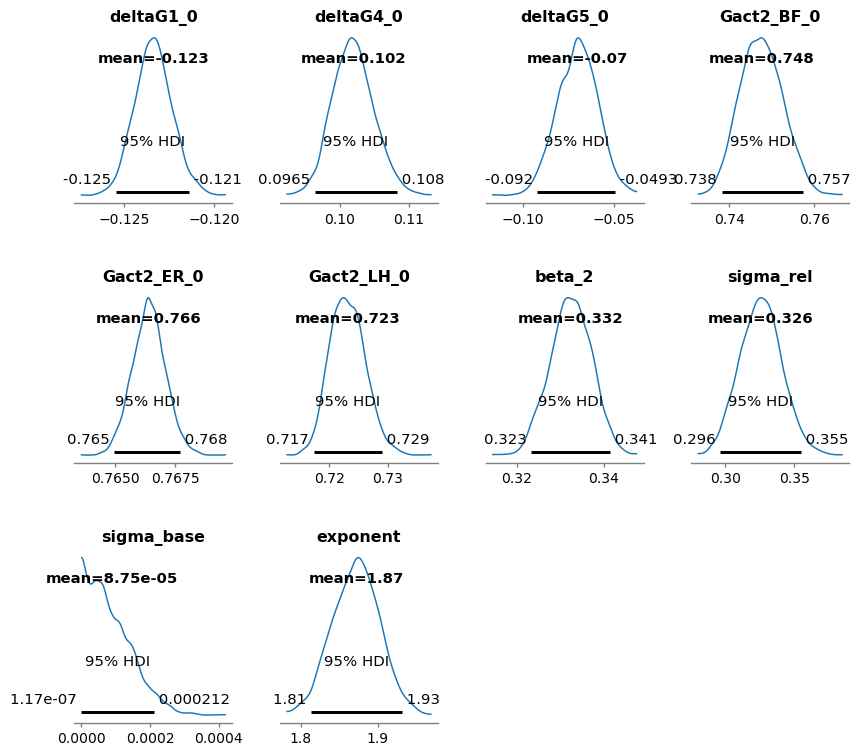

c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


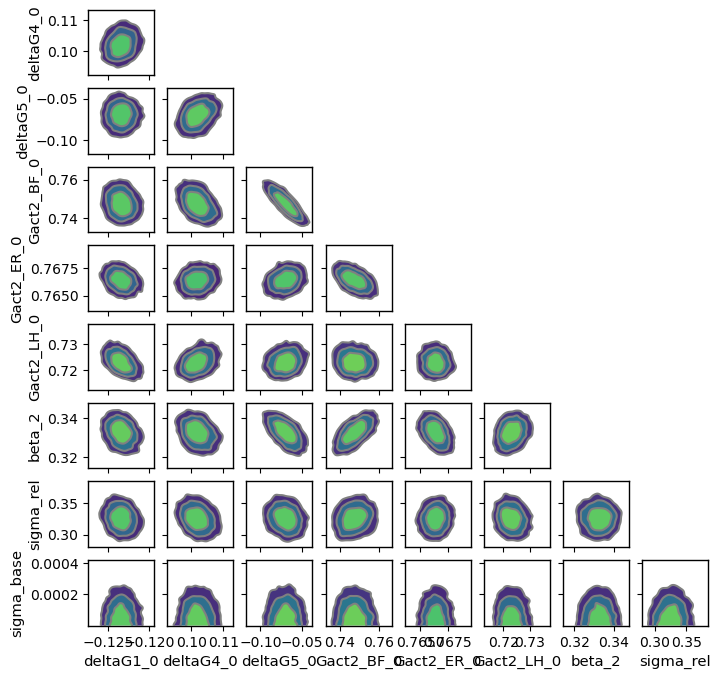

Sampling: [rate]


rate: 0.740


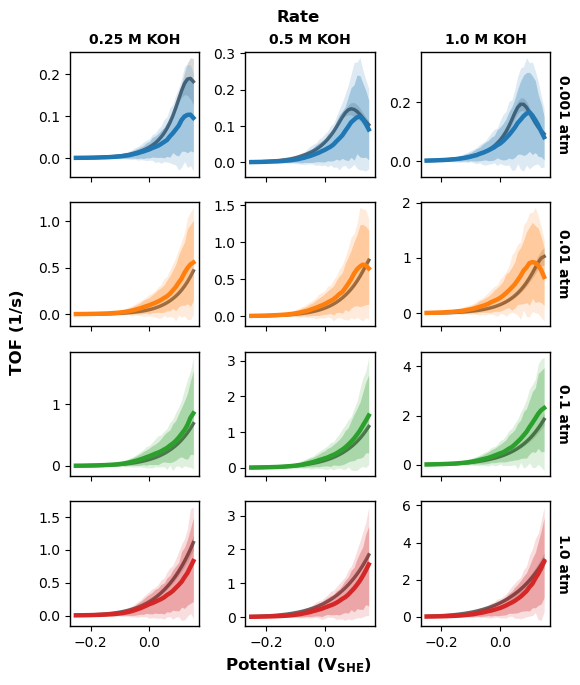

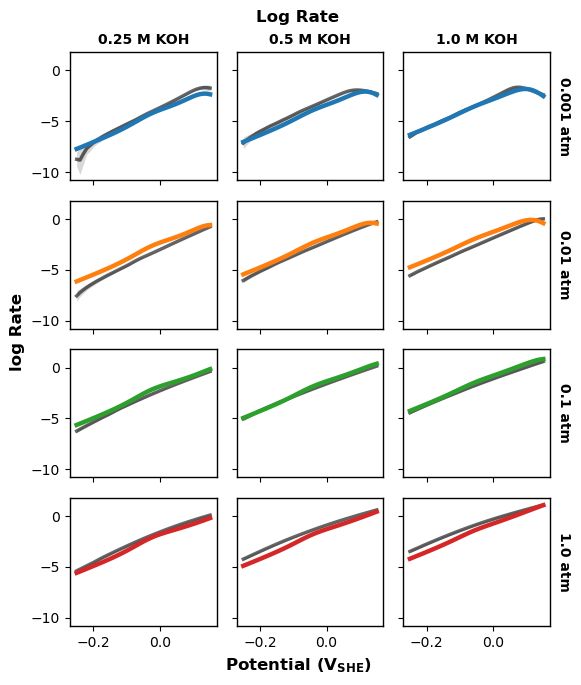

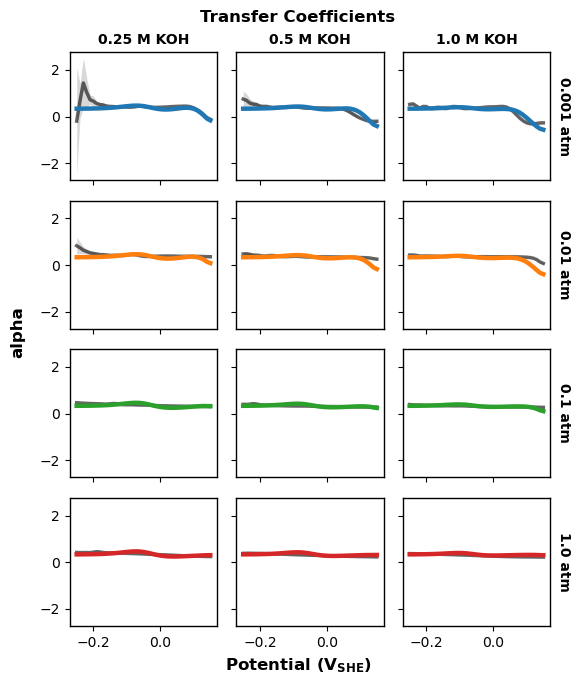

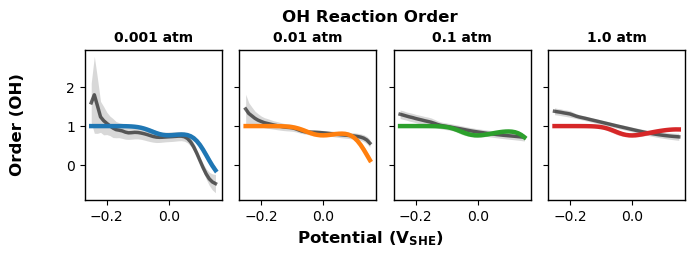

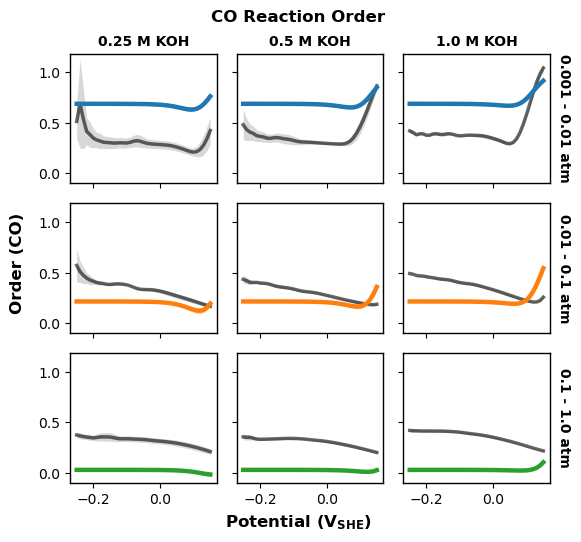

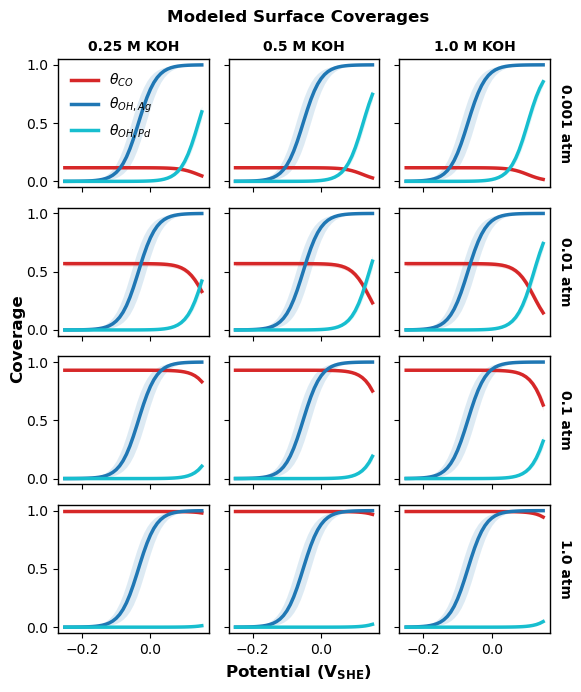

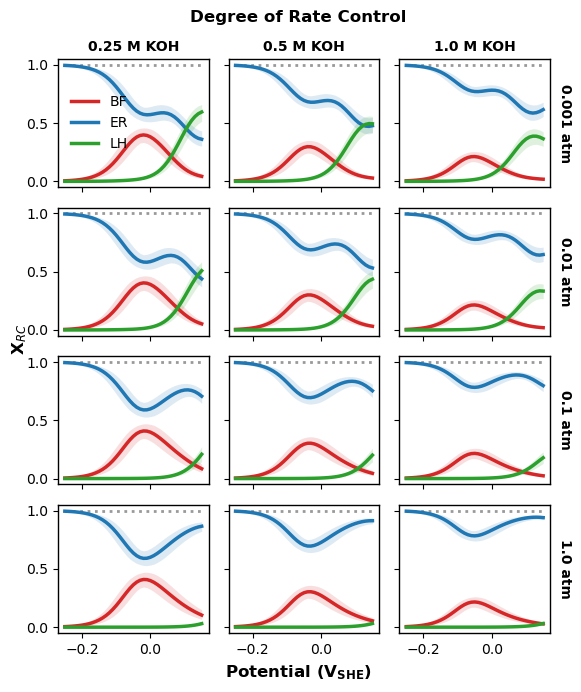

In [9]:
ppc_BF_ER_LH_2 = plot_posteriors(trace_BF_ER_LH_2, BF_ER_LH_2)
plot_model_fits(trace_BF_ER_LH_2, ppc_BF_ER_LH_2); plot_coverages(trace_BF_ER_LH_2)
plot_drc(BF_ER_LH_2, trace_BF_ER_LH_2, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0', 'Gact2_LH_0'], perturb_labels=['BF', 'ER', 'LH'])

# Partial Charge Transfer

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.23,15
,3000,0,0.23,63
,3000,0,0.22,31
,3000,0,0.23,63


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  3013.75    72.44
p_loo        9.71        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



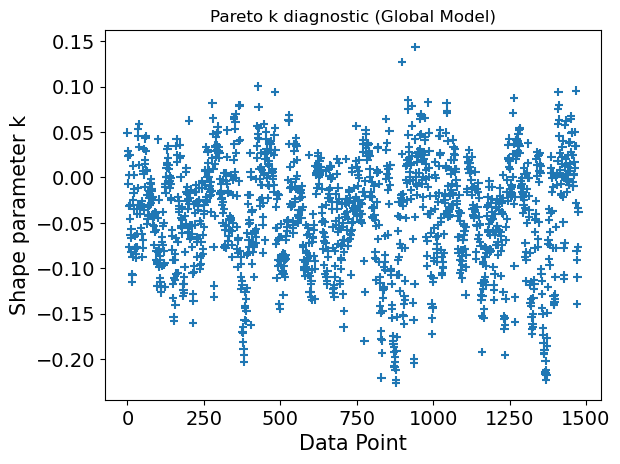

In [13]:
with pm.Model() as PCT:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(mu-1)# -> COOH* + # + (1-mu)(e-) (RDS) (BF)
    2b. CO* + OH* -> COOH* + * (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(mu-1)# + (mu)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    mu_charge = pm.Beta('mu_charge', alpha=1, beta=1)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - mu_charge * E_in
    Gact2_BF = Gact2_BF_0 - beta_2 * (1.0 - mu_charge) * E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    # log_rate = pt.logsumexp(pt.stack([log_rate_BF, log_rate_LH]), axis=0)
    log_rate = log_rate_BF
    rate = observables(log_rate) 

trace_PCT, loo_PCT = fit_and_evaluate(PCT)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.125  0.001  -0.127   -0.123      0.000    0.000    3172.0    2898.0    1.0
deltaG4_0   0.136  0.006   0.126    0.146      0.000    0.000    2469.0    2450.0    1.0
deltaG5_0   0.026  0.004   0.018    0.033      0.000    0.000     857.0    1108.0    1.0
Gact2_BF_0  0.670  0.003   0.664    0.677      0.000    0.000     809.0    1023.0    1.0
Gact2_LH_0  0.700  0.198   0.309    1.049      0.003    0.004    5181.0    2732.0    1.0
beta_2      0.123  0.030   0.062    0.176      0.001    0.001     791.0     932.0    1.0
mu_charge   0.305  0.024   0.259    0.350      0.001    0.001     900.0     964.0    1.0
sigma_rel   0.322  0.015   0.295    0.351      0.000    0.000    2910.0    2785.0    1.0
sigma_base  0.000  0.000   0.000    0.000      0.000    0.000    2194.0    1466.0    1.0
exponent    1.864  0.031   1.807    1.921      0.001    0.000    2969.0    2569.0    1.0


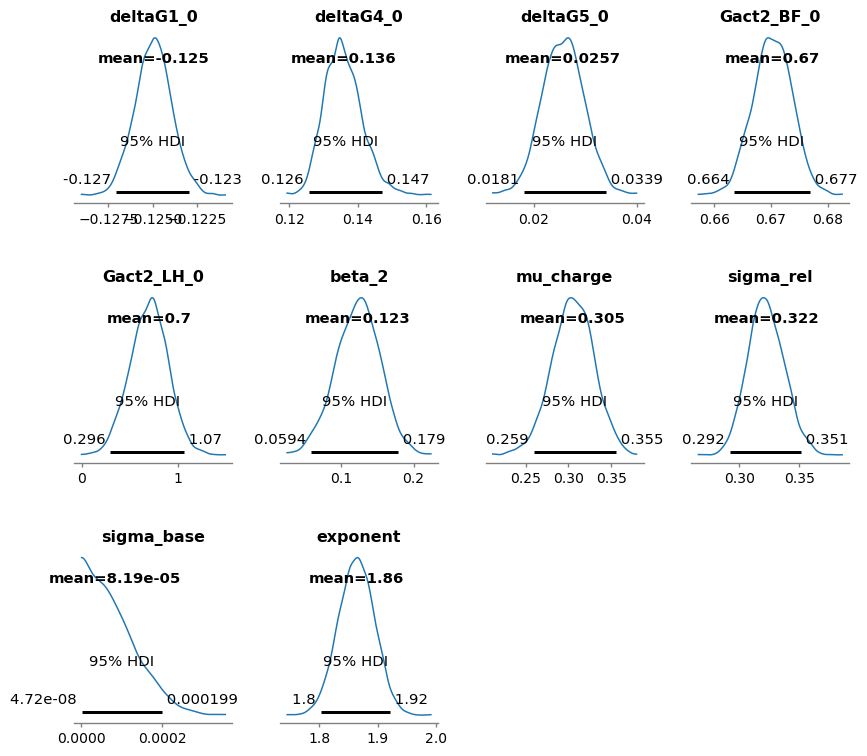

c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


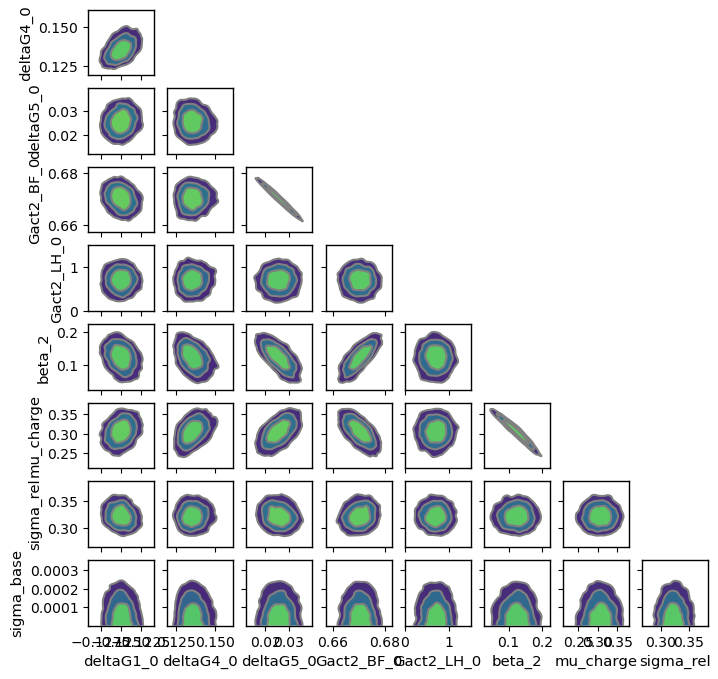

Sampling: [rate]


rate: 0.720


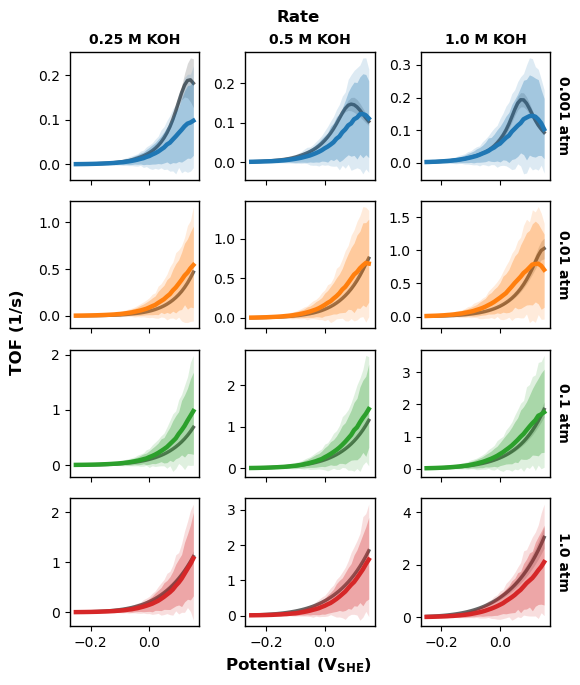

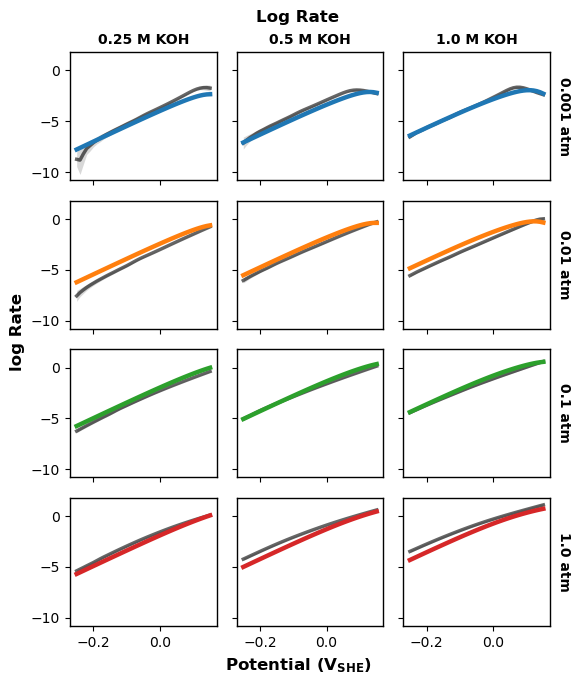

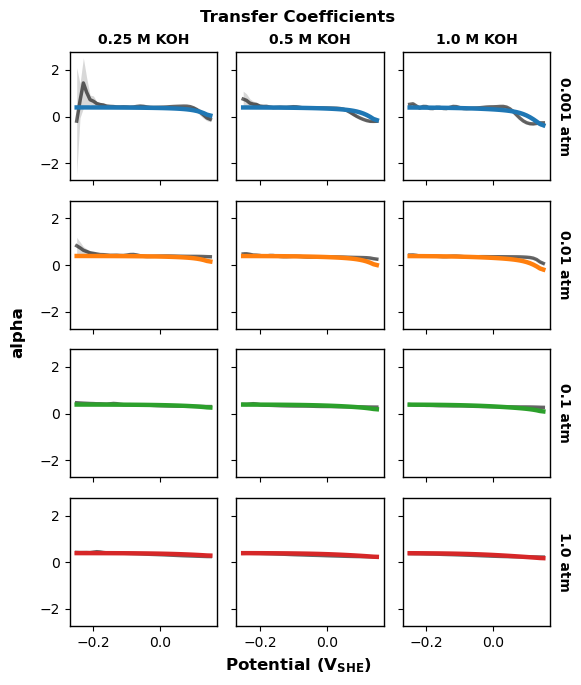

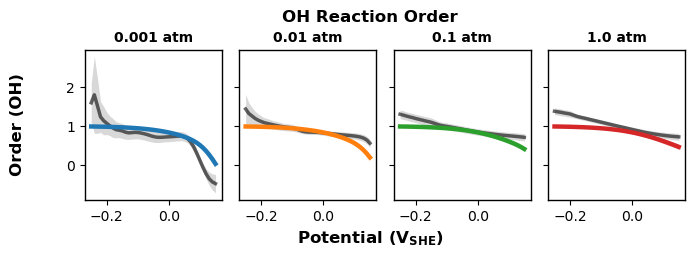

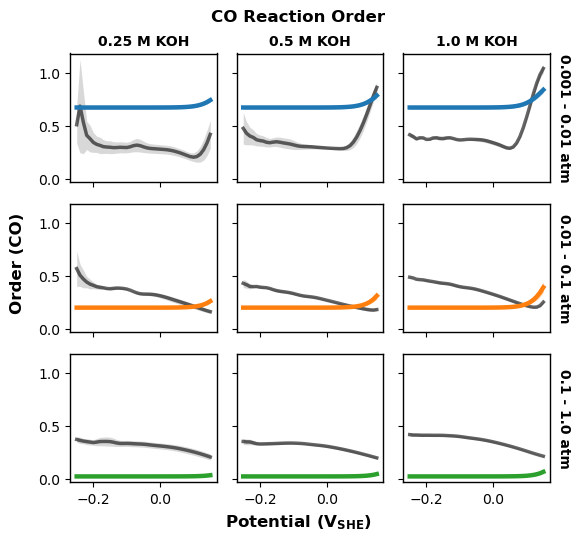

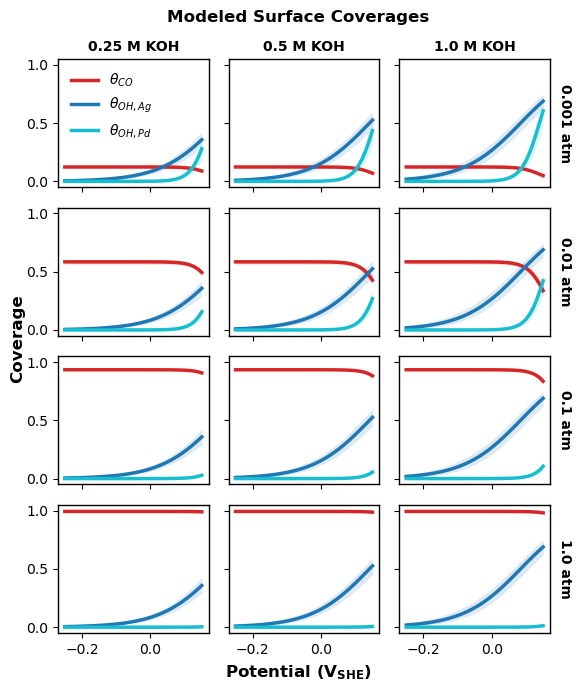

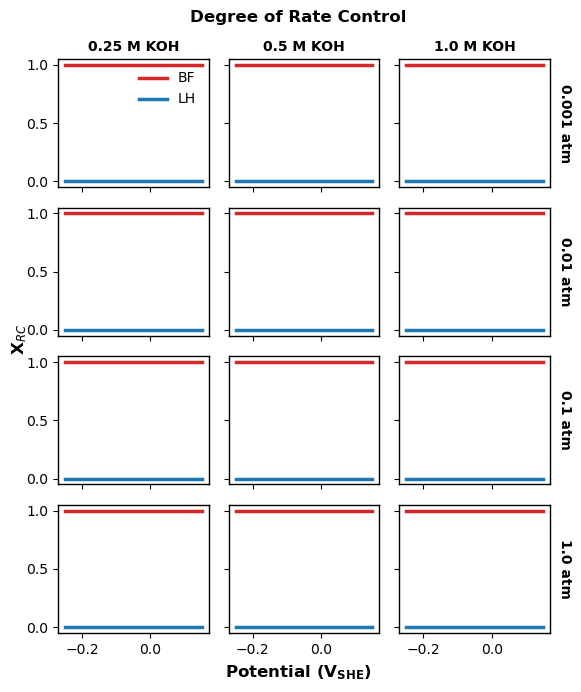

In [14]:
ppc_PCT = plot_posteriors(trace_PCT, PCT)
plot_model_fits(trace_PCT, ppc_PCT); plot_coverages(trace_PCT)
plot_drc(PCT, trace_PCT, perturb_vars=['Gact2_BF_0', 'Gact2_LH_0'], perturb_labels=['BF', 'LH'])

# Comparison

            rank     elpd_loo      p_loo    elpd_diff        weight         se        dse  warning scale
BF_ER_LH_2     0  3017.451986  13.709851     0.000000  5.421204e-01  72.252511   0.000000    False   log
PCT            1  3013.745766   9.714564     3.706220  4.426636e-01  72.444250   8.574492    False   log
BF_ER_2        2  2986.735182  12.777721    30.716804  2.849078e-09  72.467244   9.688914    False   log
ER_2           3  2941.730181   7.349106    75.721804  1.521601e-02  73.151597  14.541580    False   log
BF             4  1937.962111   7.679336  1079.489875  0.000000e+00  67.058575  27.595626    False   log


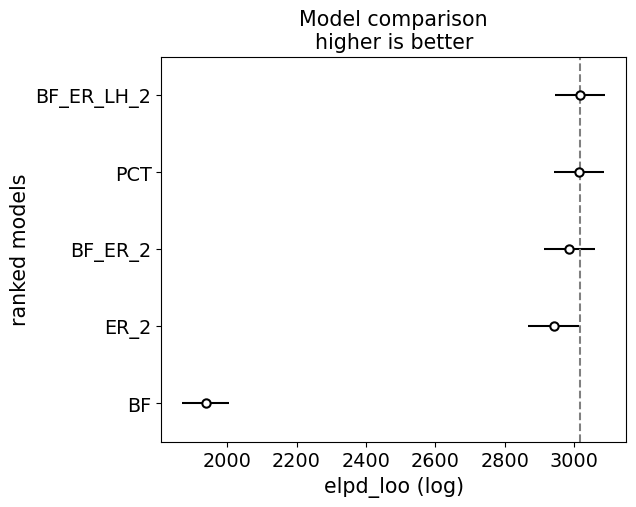

In [15]:
comparison_dict = {
    "BF": loo_BF,
    "ER_2": loo_ER_2,
    "BF_ER_2": loo_BF_ER_2,
    "BF_ER_LH_2": loo_BF_ER_LH_2,
    "PCT": loo_PCT
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()